# Time-Series Regression Case Study

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import acf

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## 1. Load data and perform a minimal global audit

In [2]:
path = "time_series_regression_case_intermediate_signal_v2.csv"
df_raw = pd.read_csv(path, parse_dates=["date"])

print("Raw shape:", df_raw.shape)
print("Date range:", df_raw["date"].min(), "to", df_raw["date"].max())
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Missing values by column:")
display(df_raw.isna().sum().to_frame("missing_count").T)
print("\nDtypes:")
display(df_raw.dtypes.astype(str).to_frame("dtype").T)

Raw shape: (1329, 8)
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
Duplicate rows: 24
Missing values by column:


,date,return_1d,lag_return,momentum_5d,momentum_20d,rolling_volatility,macro_signal,vol_regime
missing_count,0,0,0,0,0,0,0,0



Dtypes:


,date,return_1d,lag_return,momentum_5d,momentum_20d,rolling_volatility,macro_signal,vol_regime
dtype,datetime64[us],float64,float64,float64,float64,float64,float64,float64


In [3]:
summary_table = pd.DataFrame({
    "min": df_raw.drop(columns=["date"]).min(numeric_only=True),
    "max": df_raw.drop(columns=["date"]).max(numeric_only=True),
    "mean": df_raw.drop(columns=["date"]).mean(numeric_only=True),
    "std": df_raw.drop(columns=["date"]).std(numeric_only=True),
})
display(summary_table)

,min,max,mean,std
return_1d,-0.131884,0.117931,0.000579,0.034793
lag_return,-0.131884,0.117931,0.000847,0.034676
momentum_5d,-0.066929,0.067442,0.000779,0.016466
momentum_20d,-0.031299,0.038437,0.000752,0.010567
rolling_volatility,0.015000,0.053556,0.032399,0.007095
macro_signal,-2.263512,2.379838,-0.005823,1.002086
vol_regime,0.012000,0.024000,0.015837,0.005599



***To be noted***: Slight postivie drift : 0.05% daily --> will need to compare strat with a simple "hold" benchmark


I will perform an intentionally minimal and global cleaning, avoiding the use any predictive structure:
- Sorting chronologically 
- Dropping exact duplicates
- Winsorizing return_1d at 1% / 99/ 
- Leaving imputation for later, through pipeline or causal methods to avoid leakage 

In [4]:
df = df_raw.sort_values("date").drop_duplicates().reset_index(drop=True).copy()
df_pre_winsor = df.copy()
ret_lo, ret_hi = df["return_1d"].quantile([0.01, 0.99])
df["return_1d"] = df["return_1d"].clip(ret_lo, ret_hi)
print("Post-cleaning shape:", df.shape)

Post-cleaning shape: (1305, 8)


## 2. Define the prediction target

In [5]:
# Shifting returns to avoid leakage 

df["target_return_next_day"] = df["return_1d"].shift(-1)
df = df.iloc[:-1].reset_index(drop=True).copy()
df[["date", "return_1d", "target_return_next_day"]].head()

,date,return_1d,target_return_next_day
0,2020-01-01,-0.012272,-0.050325
1,2020-01-02,-0.050325,-0.010261
2,2020-01-03,-0.010261,-0.005310
3,2020-01-06,-0.005310,-0.006043
4,2020-01-07,-0.006043,0.021259


## 3. Reserve a final holdout before detailed EDA

In [6]:
holdout_frac = 0.20
holdout_size = int(len(df) * holdout_frac)

dev_df = df.iloc[:-holdout_size].copy()
holdout_df = df.iloc[-holdout_size:].copy()

display(pd.DataFrame({
    "sample": ["development", "final_holdout"],
    "rows": [len(dev_df), len(holdout_df)],
    "start_date": [dev_df["date"].min(), holdout_df["date"].min()],
    "end_date": [dev_df["date"].max(), holdout_df["date"].max()],
}))

,sample,rows,start_date,end_date
0,development,1044,2020-01-01,2024-01-01
1,final_holdout,260,2024-01-02,2024-12-30


## 4. EDA on the development sample only

### 4.1 Existing features and target

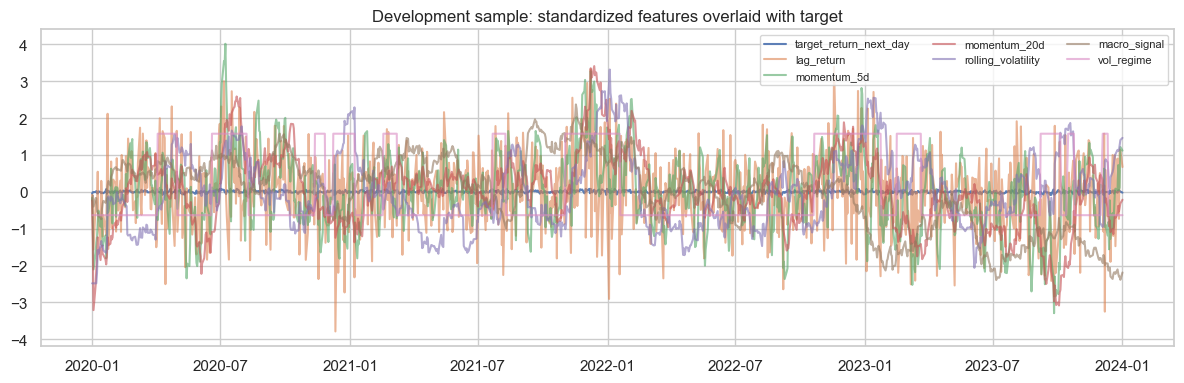

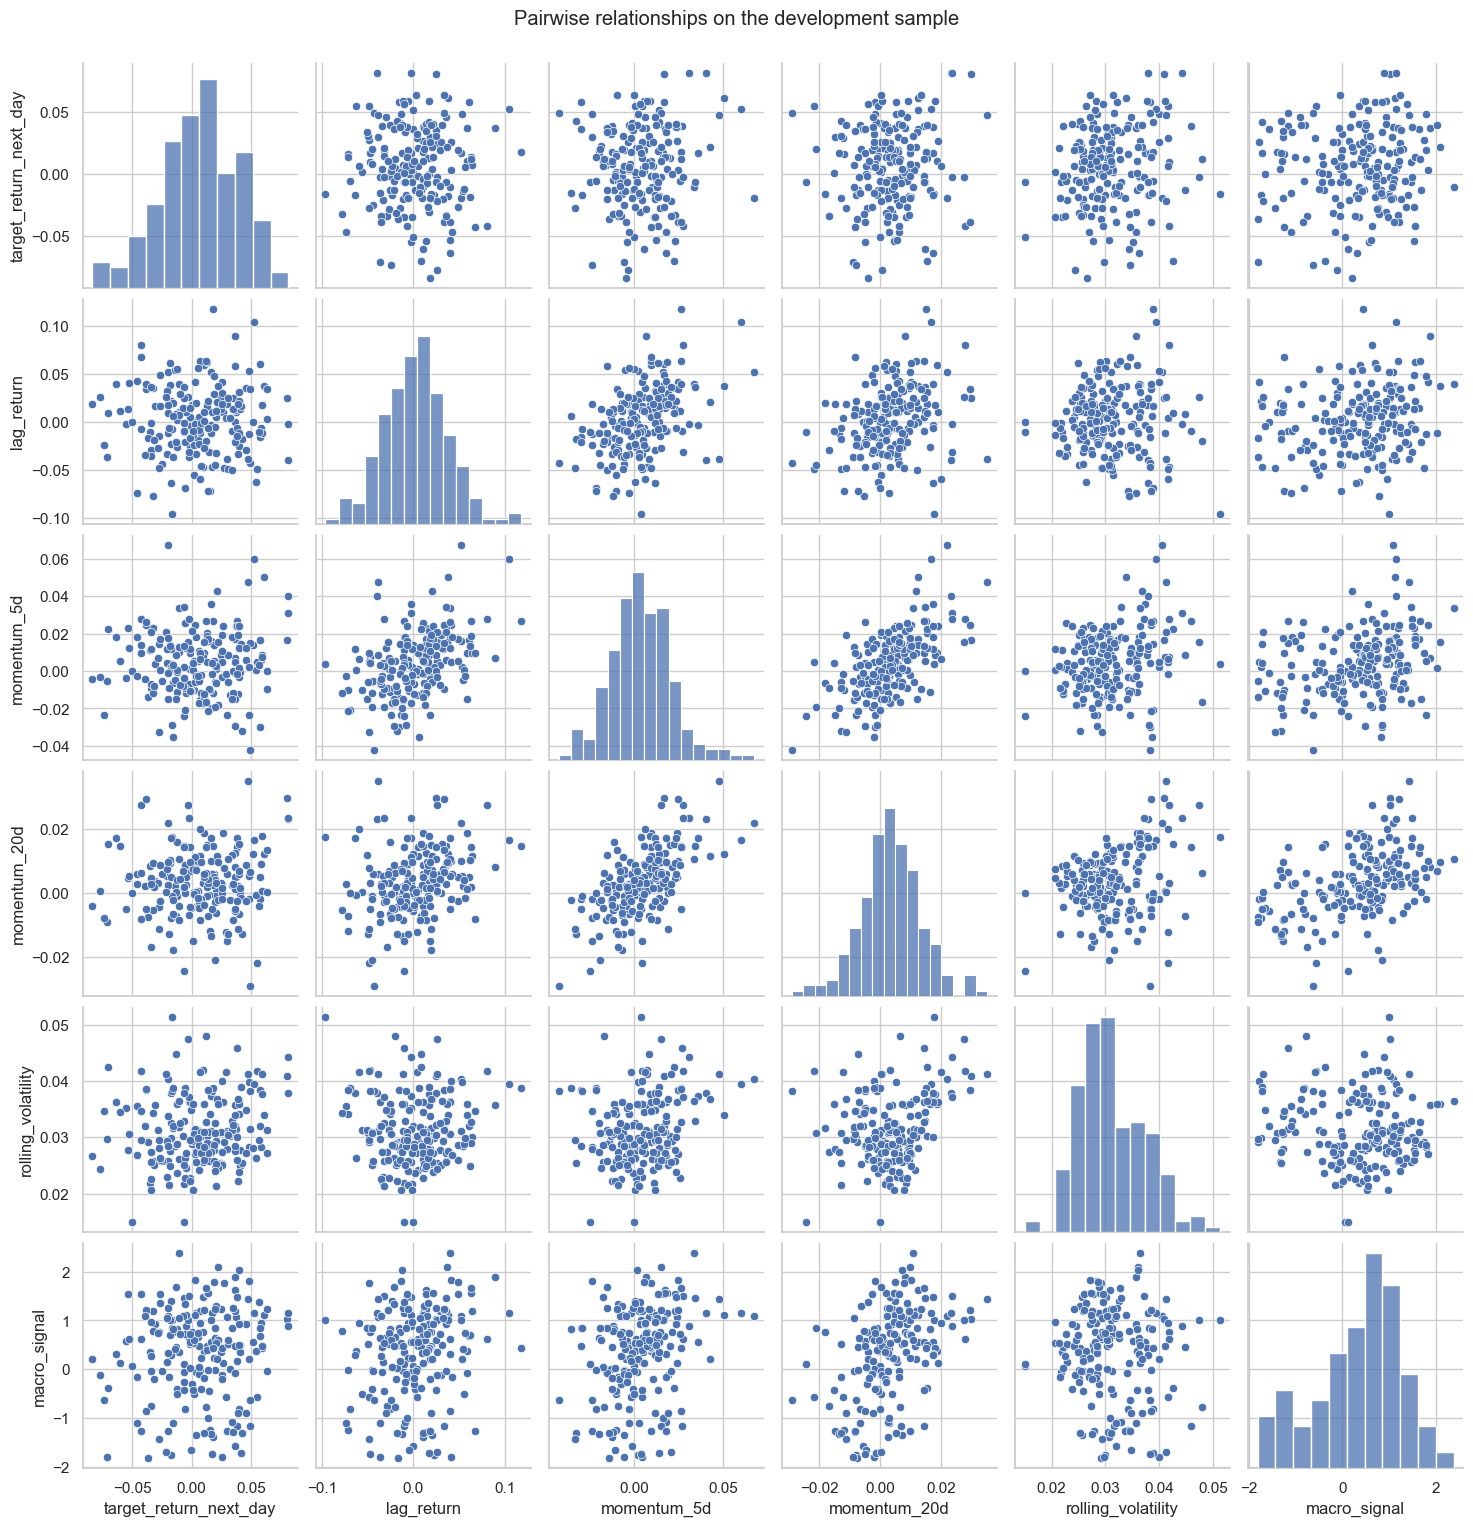

In [7]:
%matplotlib inline

plt.figure(figsize=(12, 4))
plt.plot(dev_df["date"], dev_df["target_return_next_day"], label="target_return_next_day", alpha=0.9)
for col in ["lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal", "vol_regime"]:
    z = (dev_df[col] - dev_df[col].mean()) / (dev_df[col].std() + 1e-12)
    plt.plot(dev_df["date"], z, label=col, alpha=0.6)
plt.title("Development sample: standardized features overlaid with target")
plt.legend(loc="upper right", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

pair_cols = ["target_return_next_day", "lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal"]
pair_sample = dev_df[pair_cols].dropna().sample(200)
pp = sns.pairplot(pair_sample)
pp.fig.suptitle("Pairwise relationships on the development sample", y=1.02)
plt.show()


We see some linear structure between `target_return`ans soem of the feature, notably `macro_signal`and the momentum features. We can also note the different momentum features are correlated.

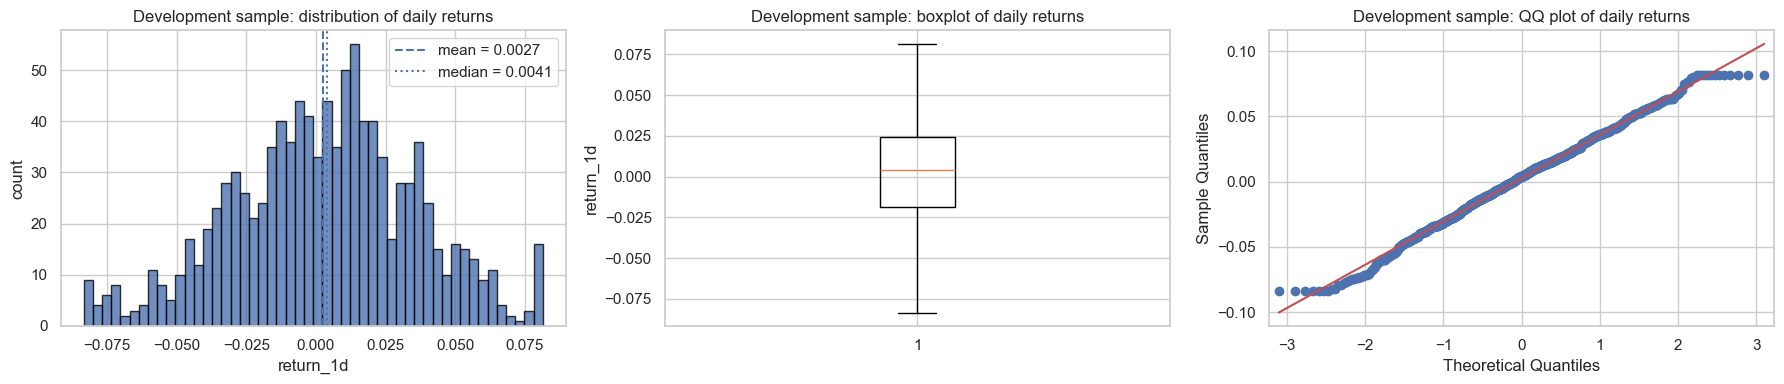

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
stat,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,excess_kurtosis
value,1044.0,0.002663,0.033168,-0.083428,-0.078393,-0.055023,-0.018802,0.004112,0.024451,0.056664,0.081426,0.081426,-0.122356,-0.111749


In [8]:
# EDA on the distribution of daily returns (development sample)

from scipy.stats import skew, kurtosis

ret = dev_df["return_1d"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
axes[0].hist(ret, bins=50, edgecolor="black", alpha=0.8)
axes[0].axvline(ret.mean(), linestyle="--", label=f"mean = {ret.mean():.4f}")
axes[0].axvline(ret.median(), linestyle=":", label=f"median = {ret.median():.4f}")
axes[0].set_title("Development sample: distribution of daily returns")
axes[0].set_xlabel("return_1d")
axes[0].set_ylabel("count")
axes[0].legend()

# Boxplot
axes[1].boxplot(ret, vert=True)
axes[1].set_title("Development sample: boxplot of daily returns")
axes[1].set_ylabel("return_1d")

# QQ plot
sm.qqplot(ret, line="s", ax=axes[2])
axes[2].set_title("Development sample: QQ plot of daily returns")

plt.tight_layout()
plt.show()

return_dist_summary = pd.DataFrame({
    "stat": [
        "count", "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max",
        "skewness", "excess_kurtosis"
    ],
    "value": [
        ret.count(),
        ret.mean(),
        ret.std(),
        ret.min(),
        ret.quantile(0.01),
        ret.quantile(0.05),
        ret.quantile(0.25),
        ret.quantile(0.50),
        ret.quantile(0.75),
        ret.quantile(0.95),
        ret.quantile(0.99),
        ret.max(),
        skew(ret, bias=False),
        kurtosis(ret, fisher=True, bias=False),
    ]
})

display(return_dist_summary.T)

--> 
- Daily returns are centered close to zero, with a small positive drift (~0.26%), which remains negligible relative to the overall volatility (~3.3%)
- The distribution is broadly symmetric, with a slightly negative skew (-0.12), suggesting somewhat heavier downside tails
- The QQ plot shows mild deviations from normality in the tails, although the central part of the distribution is reasonably well aligned with a Gaussian
- Extreme values are present but not dominant, which is consistent with the earlier winsorization step

Overall, the distribution is close to Gaussian in the center but exhibits the typical tail behavior observed in financial returns, implying that models relying strictly on normality assumptions should be interpreted with caution

In [9]:
# ADF test on daily returns (development sample)

from statsmodels.tsa.stattools import adfuller

ret = dev_df["return_1d"].dropna()

adf_stat, adf_pvalue, _, _, adf_crit, _ = adfuller(ret, autolag="AIC")

adf_table = pd.DataFrame({
    "test": ["ADF"],
    "null_hypothesis": ["unit root / non-stationary"],
    "test_stat": [adf_stat],
    "p_value": [adf_pvalue],
})

display(adf_table)

print("ADF critical values:", adf_crit)

,test,null_hypothesis,test_stat,p_value
0,ADF,unit root / non-stationary,-11.003556,6.589755e-20


ADF critical values: {'1%': np.float64(-3.4366655541494944), '5%': np.float64(-2.8643284548748533), '10%': np.float64(-2.5682546880209087)}



--> The ADF test strongly rejects the unit root hypothesis (p-value ≪ 1%), suggesting that daily returns can be treated as stationary in mean
--> Applying standard regression models on returns is theoretically justified from a stationarity perspective.

### 4.2 Lag diagnostics

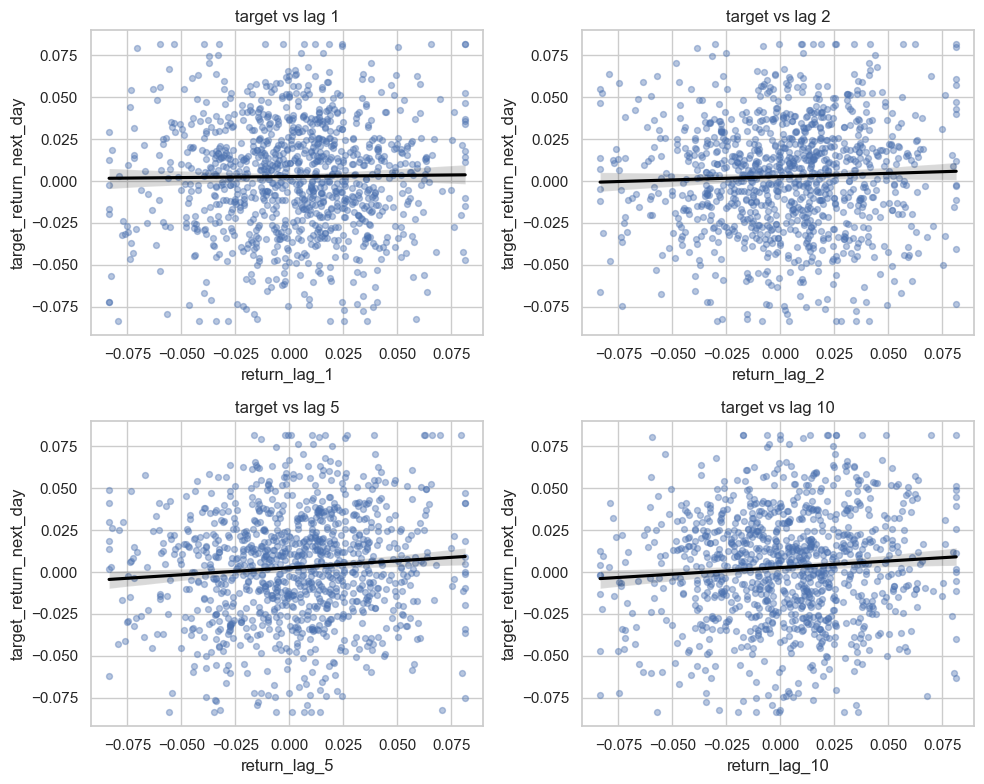

In [10]:
lag_diag = dev_df[["date", "target_return_next_day"]].copy()
for lag in [1, 2, 5, 10]:
    lag_diag[f"return_lag_{lag}"] = dev_df["return_1d"].shift(lag)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, lag in zip(axes.ravel(), [1, 2, 5, 10]):
    sns.regplot(data=lag_diag, x=f"return_lag_{lag}", y="target_return_next_day", ax=ax,
                scatter_kws={"alpha":0.4, "s":18}, line_kws={"color":"black"})
    ax.set_title(f"target vs lag {lag}")
plt.tight_layout()
plt.show()


--> No sign of strong autocorrelation 

### 4.3 Momentum diagnostics

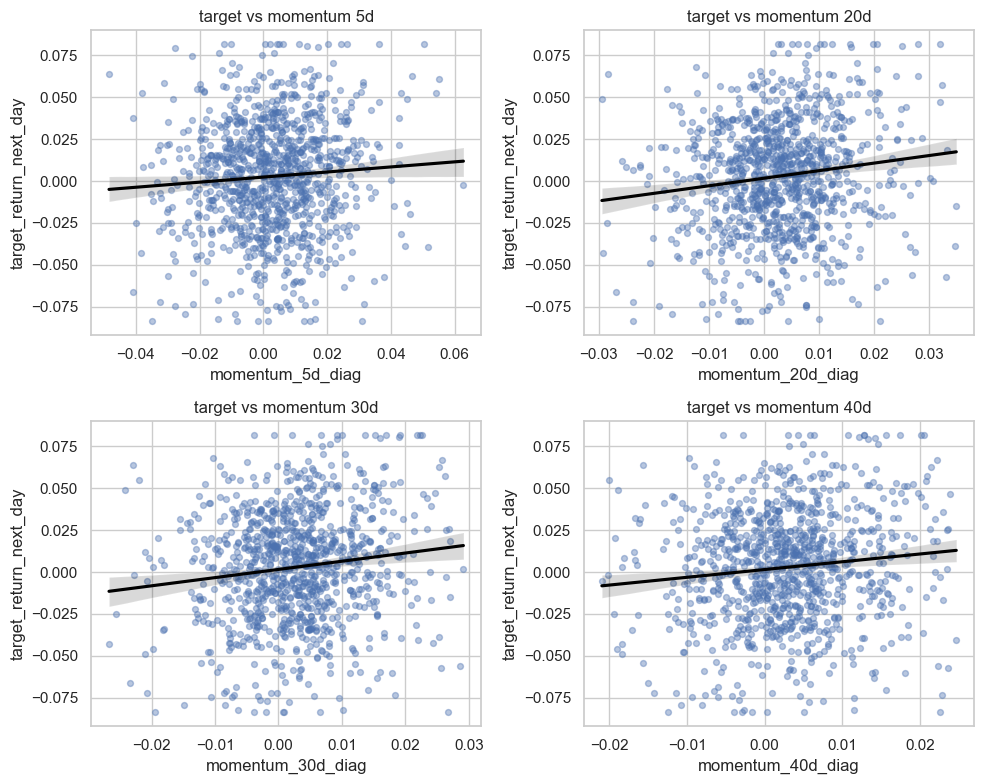

In [11]:

mom_diag = dev_df[["date", "target_return_next_day", "return_1d"]].copy()
for window in [5, 20, 30, 40]:
    mom_diag[f"momentum_{window}d_diag"] = dev_df["return_1d"].rolling(window).mean()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, window in zip(axes.ravel(), [5, 20, 30, 40]):
    sns.regplot(data=mom_diag, x=f"momentum_{window}d_diag", y="target_return_next_day", ax=ax,
                scatter_kws={"alpha":0.4, "s":18}, line_kws={"color":"black"})
    ax.set_title(f"target vs momentum {window}d")
plt.tight_layout()
plt.show()


--> Weak sign of momentum behavior

### 4.4 Correlation screen for all inspected variables

In [12]:
eda_corr = dev_df[["target_return_next_day", "lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal", "vol_regime"]].copy()
for lag in [1, 2, 5, 10]:
    eda_corr[f"return_lag_{lag}"] = dev_df["return_1d"].shift(lag)
for window in [30, 40]:
    eda_corr[f"momentum_{window}d_diag"] = dev_df["return_1d"].rolling(window).mean()

corr_table = eda_corr.corr(numeric_only=True)[["target_return_next_day"]].drop(index=["target_return_next_day"])
corr_table = corr_table.rename(columns={"target_return_next_day": "corr_with_target"}).sort_values("corr_with_target", ascending=False)
display(corr_table)


,corr_with_target
macro_signal,0.166691
momentum_20d,0.136262
momentum_30d_diag,0.130184
momentum_40d_diag,0.112908
momentum_5d,0.096743
return_lag_5,0.082884
return_lag_10,0.078426
vol_regime,0.053829
rolling_volatility,0.050196
return_lag_2,0.039150


--> Relatively high correlation with macro_signal and momentum_20d, suggesting they will be good candidates to extract predictive power

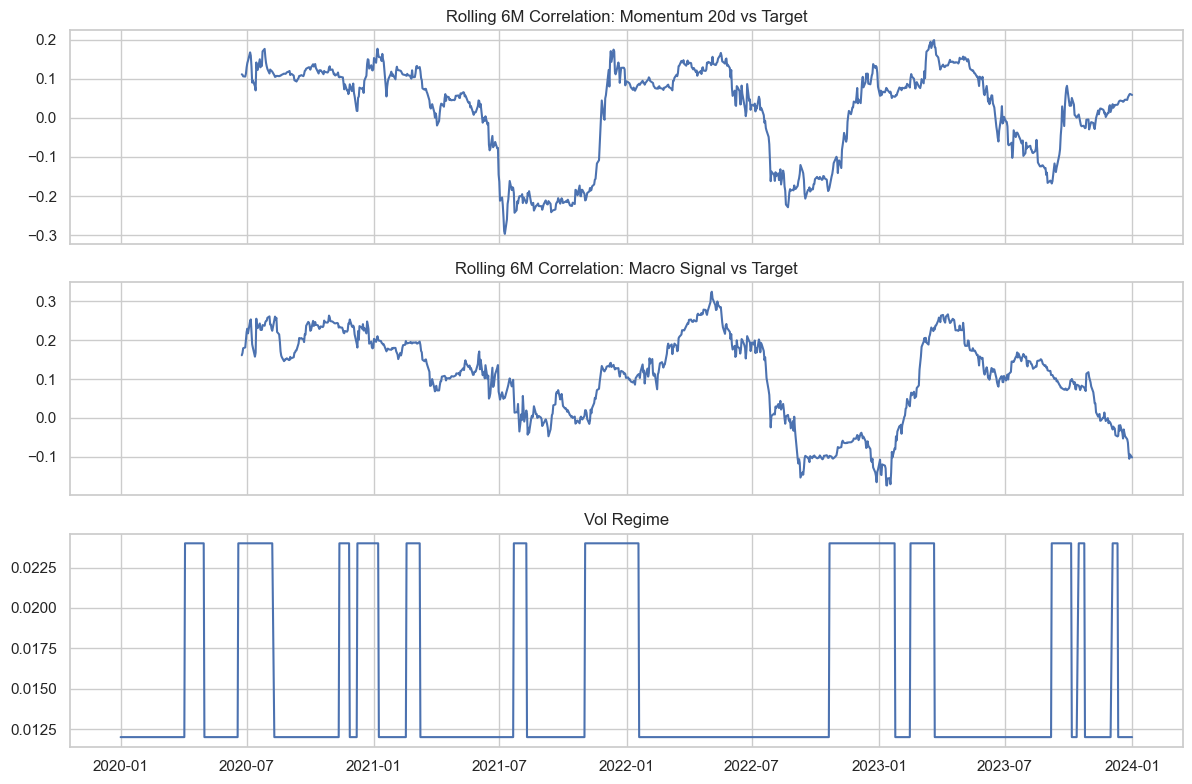

In [13]:
# Inspecting robustness of macro-target and momentum-target correlation through time

window = 126  # ~6 months of trading days

tmp = dev_df.copy()

# Rolling correlations
tmp["corr_mom20_target"] = tmp["momentum_20d"].rolling(window).corr(tmp["target_return_next_day"])
tmp["corr_macro_target"] = tmp["macro_signal"].fillna(0).rolling(window).corr(tmp["target_return_next_day"])

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# (1) Momentum 20d vs target
axes[0].plot(tmp["date"], tmp["corr_mom20_target"])
axes[0].set_title("Rolling 6M Correlation: Momentum 20d vs Target")

# (2) Macro signal vs target
axes[1].plot(tmp["date"], tmp["corr_macro_target"])
axes[1].set_title("Rolling 6M Correlation: Macro Signal vs Target")

# (3) Vol regime
axes[2].plot(tmp["date"], tmp["vol_regime"])
axes[2].set_title("Vol Regime")

plt.tight_layout()
plt.show()

In [14]:
tmp = dev_df.copy()
tmp["target"] = tmp["target_return_next_day"]

res = tmp.groupby("vol_regime").apply(
    lambda g: pd.Series({
        "corr_mom20": g["momentum_20d"].corr(g["target"]),
        "corr_macro": g["macro_signal"].corr(g["target"]),
        "n": len(g)
    })
)
print(res)

            corr_mom20  corr_macro      n
vol_regime                               
0.012         0.024894    0.106864  745.0
0.024         0.236916    0.278454  299.0



--> The signal concentrates in high-volatility regimes. A plausible interpretation is that macro information propagates more slowly and nonlinearly during stress, creating temporary inefficiencies. Outside those regimes, the signal largely disappears

--> This is pushing for the creation of regime dependent features

Note: Given the relatively small dataset (~1300 observations), reducing feature redundancy will help limit overfitting and improves generalization. Thus, I will not add any additional lag features given the absence of autocorrelation evidence, and I will keep only the 20_day momentum feature as all momentum features are highly correlated and the 20d one seems to be the one best capturing the trend. 

### 4.5 Feature significance with Newey-West standard errors

Before engineering new features, I formally test whether the existing variables predict next-day returns. Since financial return residuals may exhibit autocorrelation, I use Newey-West (HAC) standard errors rather than HC3. I also split by volatility regime to test whether the signal is regime-dependent, as suggested by the conditional correlations in §4.4.

In [15]:
# ── Full-sample OLS with Newey-West SEs ──
sig_cols = ["lag_return", "momentum_5d", "momentum_20d", "rolling_volatility", "macro_signal"]
sig_df = dev_df[["target_return_next_day"] + sig_cols].dropna()

formula = "target_return_next_day ~ " + " + ".join(sig_cols)
ols_full = smf.ols(formula=formula, data=sig_df).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print("── Full development sample ──")
print(ols_full.summary())

── Full development sample ──
                              OLS Regression Results                              
Dep. Variable:     target_return_next_day   R-squared:                       0.036
Model:                                OLS   Adj. R-squared:                  0.031
Method:                     Least Squares   F-statistic:                     7.669
Date:                    Thu, 28 May 2026   Prob (F-statistic):           4.32e-07
Time:                            17:18:46   Log-Likelihood:                 2094.0
No. Observations:                    1044   AIC:                            -4176.
Df Residuals:                        1038   BIC:                            -4146.
Df Model:                               5                                         
Covariance Type:                      HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In [16]:
# ── Per-regime OLS ──
sig_df_regime = dev_df[["target_return_next_day", "vol_regime"] + sig_cols].dropna()
sig_df_regime["is_high_vol"] = (sig_df_regime["vol_regime"] > 0.018).astype(int)

for regime, label in [(1, "High volatility"), (0, "Low volatility")]:
    subset = sig_df_regime[sig_df_regime["is_high_vol"] == regime]
    if len(subset) < 30:
        print(f"\n── {label}: too few observations ({len(subset)}) ──")
        continue
    fit = smf.ols(formula=formula, data=subset).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    print(f"\n── {label} (n={len(subset)}) ──")
    coefs = pd.DataFrame({"coef": fit.params, "p_value": fit.pvalues}).drop("Intercept")
    display(coefs.round(4))


── High volatility (n=299) ──


,coef,p_value
lag_return,-0.0194,0.7243
momentum_5d,-0.0790,0.6179
momentum_20d,0.4463,0.0618
rolling_volatility,-0.1785,0.5812
macro_signal,0.0097,0.0008



── Low volatility (n=745) ──


,coef,p_value
lag_return,-0.0453,0.2686
momentum_5d,0.0416,0.6834
momentum_20d,-0.0875,0.5634
rolling_volatility,0.3045,0.1889
macro_signal,0.0042,0.0045


**Full sample** (n = 1,044, R² = 0.036, F-test p = 4.3e-7): the features are collectively significant. Individually, **`macro_signal`** is the only clearly significant predictor (coef = 0.0054, p < 0.001). `rolling_volatility` is borderline (p = 0.076). `momentum_20d` (p = 0.156), `momentum_5d` (p = 0.63), and `lag_return` (p = 0.33) are non-significant.

**Per-regime split**: the picture changes materially.
- **High volatility** (n = 299): `macro_signal` is highly significant (coef = 0.0097, p = 0.0008) with a coefficient nearly twice the full-sample estimate. `momentum_20d` becomes borderline significant (coef = 0.446, p = 0.062).
- **Low volatility** (n = 745): `macro_signal` remains significant (coef = 0.0042, p = 0.0045) but with a smaller effect. `momentum_20d` is non-significant (p = 0.56).

The regime split confirms the EDA finding in §4.4: `macro_signal` carries genuine predictive power in both regimes, but the effect roughly doubles in high-vol. `momentum_20d` contributes only in high-vol. This motivates creating regime-dependent interaction features (`macro_high_vol`, `mom20_high_vol`) in §5, to let models exploit the stronger high-vol signal without contaminating the coefficient with the weaker low-vol relationship.

## 5. Feature creation for modeling

In [17]:
feat_df = df.copy()

# ── Causal macro imputation ──
macro_expanding_mean = feat_df["macro_signal"].expanding().mean().shift(1)
feat_df["macro_signal"] = feat_df["macro_signal"].fillna(macro_expanding_mean)
feat_df["macro_signal"] = feat_df["macro_signal"].fillna(feat_df["macro_signal"].median())

# ── Vol normalization ──
den = feat_df["rolling_volatility"].replace(0, np.nan)
feat_df["mom20_over_vol"] = feat_df["momentum_20d"] / den
feat_df["lag_over_vol"] = feat_df["lag_return"] / den

# ── Regime indicator (no leakage: fixed threshold) ──
feat_df["is_high_vol"] = (feat_df["vol_regime"] > 0.018).astype(int)

# ── Regime-dependent features (motivated by §4.5) ──
feat_df["macro_high_vol"] = feat_df["macro_signal"] * feat_df["is_high_vol"]
feat_df["mom20_high_vol"] = feat_df["momentum_20d"] * feat_df["is_high_vol"]

# ── Final cleanup ──
feat_df = feat_df.dropna().reset_index(drop=True)

# ── Feature list via select_dtypes + exclusion ──
excluded_cols = {"date", "return_1d", "target_return_next_day", "vol_regime"}
features = [c for c in feat_df.columns if c not in excluded_cols]
features = feat_df[features].select_dtypes(include=np.number).columns.tolist()

print("Feature matrix shape:", feat_df[features].shape)
display(pd.DataFrame({"feature": features}))

Feature matrix shape: (1304, 10)


,feature
0,lag_return
1,momentum_5d
2,momentum_20d
3,rolling_volatility
4,macro_signal
5,mom20_over_vol
6,lag_over_vol
7,is_high_vol
8,macro_high_vol
9,mom20_high_vol


## 6. Development split for model selection

In [18]:
holdout_size_feat = int(len(feat_df) * holdout_frac)

dev_fe = feat_df.iloc[:-holdout_size_feat].copy()
holdout_fe = feat_df.iloc[-holdout_size_feat:].copy()

test_frac = 0.20
test_size = int(len(dev_fe) * test_frac)
train_df = dev_fe.iloc[:-test_size].copy()
test_df = dev_fe.iloc[-test_size:].copy()

display(pd.DataFrame({
    "sample": ["train", "test", "holdout"],
    "rows": [len(train_df), len(test_df), len(holdout_fe)],
    "start_date": [train_df["date"].min(), test_df["date"].min(), holdout_fe["date"].min()],
    "end_date": [train_df["date"].max(), test_df["date"].max(), holdout_fe["date"].max()],
}))

X_train = train_df[features]
y_train = train_df["target_return_next_day"]
X_test = test_df[features]
y_test = test_df["target_return_next_day"]
X_holdout = holdout_fe[features]
y_holdout = holdout_fe["target_return_next_day"]

,sample,rows,start_date,end_date
0,train,836,2020-01-01,2023-03-15
1,test,208,2023-03-16,2024-01-01
2,holdout,260,2024-01-02,2024-12-30


## 7. Models

In [19]:
# ── Ridge ──
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])
ridge_grid = {"model__alpha": np.logspace(-2, 2, 8)}
tscv = TimeSeriesSplit(n_splits=5)

grid_ridge = GridSearchCV(ridge_pipe, ridge_grid, cv=tscv, scoring="neg_mean_squared_error", n_jobs=1)
grid_ridge.fit(X_train, y_train)
ridge_best = grid_ridge.best_estimator_
ridge_pred_test = ridge_best.predict(X_test)

# ── Random Forest ──
rf_pipe = Pipeline([("model", RandomForestRegressor(random_state=RANDOM_STATE))])
rf_grid = {"model__n_estimators": [50, 150, 300, 500],
           "model__max_depth": [2, 4, 6],
           "model__min_samples_leaf": [5, 10, 20]}
grid_rf = GridSearchCV(rf_pipe, rf_grid, cv=tscv, scoring="neg_mean_squared_error", n_jobs=1)
grid_rf.fit(X_train, y_train)
rf_best = grid_rf.best_estimator_
rf_pred_test = rf_best.predict(X_test)

# ── Naive baseline ──
naive_pred_test = np.full(len(y_test), y_train.mean())

# ── Results ──
results = []
for label, pred in [("Naive mean", naive_pred_test), ("Ridge", ridge_pred_test), ("RF", rf_pred_test)]:
    corr = float(np.corrcoef(y_test, pred)[0, 1]) if np.std(pred) > 1e-12 else np.nan
    results.append({"model": label,
        "rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "r2": float(r2_score(y_test, pred)), "corr": corr})

display(pd.DataFrame(results).sort_values("rmse"))
print("Best Ridge alpha:", grid_ridge.best_params_)
print("Best RF params:", grid_rf.best_params_)

,model,rmse,r2,corr
2,RF,0.032931,0.009364,0.147110
1,Ridge,0.033011,0.004540,0.075307
0,Naive mean,0.034264,-0.072465,NaN


Best Ridge alpha: {'model__alpha': np.float64(100.0)}
Best RF params: {'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}


Ridge and RF are both marginally better than the naive baseline in terms of RMSE (0.033 vs 0.034). RF shows a higher test correlation (0.147 vs 0.075) but the R² values remain very low (0.009 and 0.005 respectively). The best Ridge alpha of 100 indicates very strong regularization, consistent with a weak signal that the model must shrink aggressively to avoid overfitting noise.

## 8. Inspect the Ridge and RF models

In [20]:
ridge_coef = pd.DataFrame({
    "feature": features,
    "coef": ridge_best.named_steps["model"].coef_
}).sort_values("coef", ascending=False)
display(ridge_coef)

,feature,coef
4,macro_signal,0.002805
8,macro_high_vol,0.002776
9,mom20_high_vol,0.001670
2,momentum_20d,0.001218
0,lag_return,0.000865
7,is_high_vol,0.000707
3,rolling_volatility,0.000030
5,mom20_over_vol,-0.000128
1,momentum_5d,-0.000659
6,lag_over_vol,-0.002158


In [21]:
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_best.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)
display(rf_importance)

,feature,importance
8,macro_high_vol,0.453705
9,mom20_high_vol,0.155396
4,macro_signal,0.144651
0,lag_return,0.052768
5,mom20_over_vol,0.051117
3,rolling_volatility,0.041501
2,momentum_20d,0.037210
6,lag_over_vol,0.036014
1,momentum_5d,0.027637
7,is_high_vol,0.000000


Both models are consistent in identifying the dominant features. Ridge places `macro_signal` (0.0028) and `macro_high_vol` (0.0028) at the top, followed by `mom20_high_vol` (0.0017). The RF importance ranking is even more concentrated: `macro_high_vol` accounts for **45.4%** of total importance, with `mom20_high_vol` (15.5%) and `macro_signal` (14.5%) distant seconds.

The convergence between a linear (Ridge) and a nonlinear (RF) model on the same feature hierarchy suggests the relationships are predominantly linear. If the regime interactions had complex nonlinear structure beyond the multiplicative terms, the RF would exploit them differently. The Ridge coefficients are very small in absolute terms, consistent with the extreme regularization (alpha = 100).

## 9. Ridge and RF diagnostics on the test set

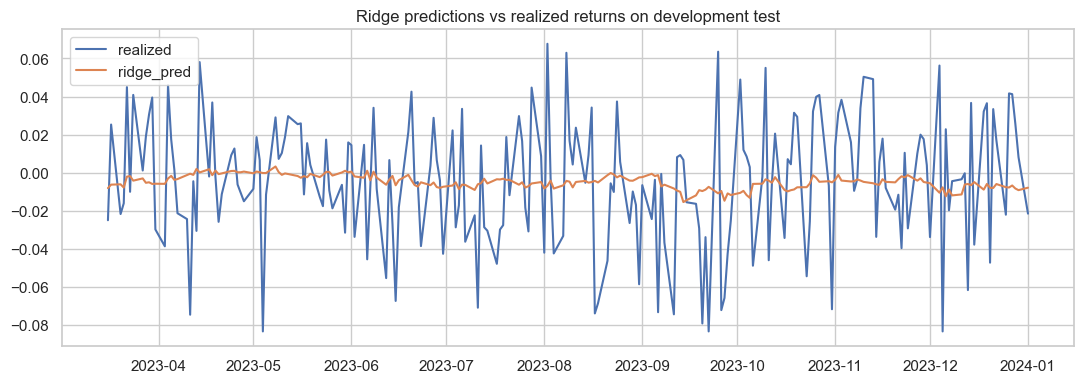

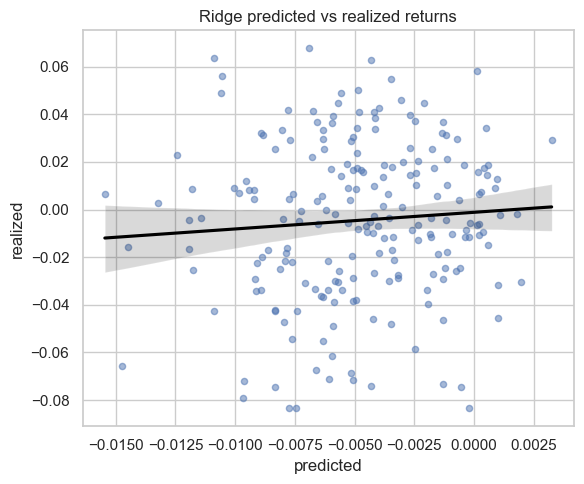

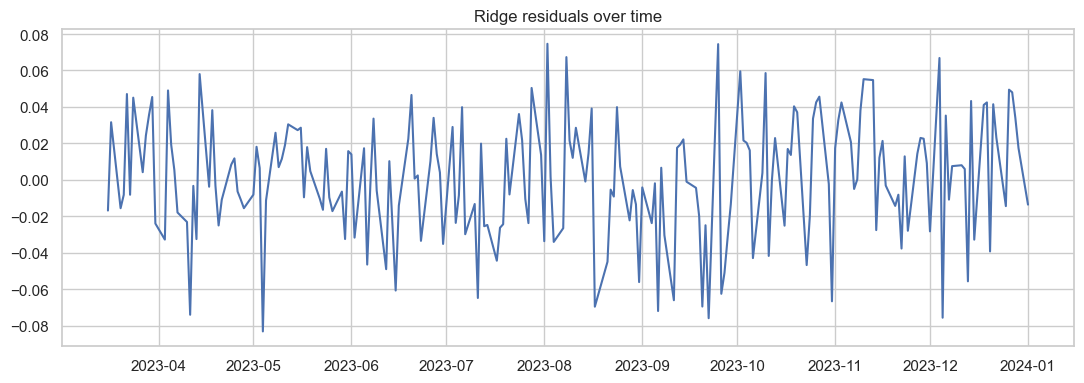

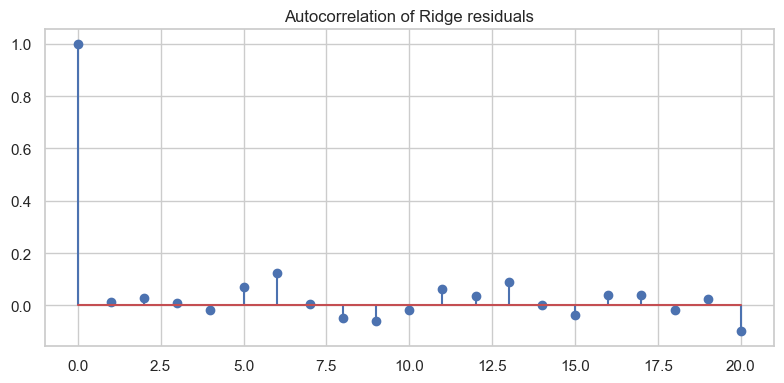

,lb_stat,lb_pvalue
5,1.380685,0.926414
10,5.926139,0.821430


In [22]:
# Ridge 

ridge_diag = pd.DataFrame({
    "date": test_df["date"].values,
    "realized": y_test.values,
    "predicted": ridge_pred_test,
})
ridge_diag["residual"] = ridge_diag["realized"] - ridge_diag["predicted"]

plt.figure(figsize=(11, 4))
plt.plot(ridge_diag["date"], ridge_diag["realized"], label="realized")
plt.plot(ridge_diag["date"], ridge_diag["predicted"], label="ridge_pred")
plt.title("Ridge predictions vs realized returns on development test")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.regplot(data=ridge_diag, x="predicted", y="realized", scatter_kws={"alpha":0.5, "s":20}, line_kws={"color":"black"})
plt.title("Ridge predicted vs realized returns")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(ridge_diag["date"], ridge_diag["residual"])
plt.title("Ridge residuals over time")
plt.tight_layout()
plt.show()

acf_vals = acf(ridge_diag["residual"], nlags=20, fft=False)
plt.figure(figsize=(8, 4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.title("Autocorrelation of Ridge residuals")
plt.tight_layout()
plt.show()

display(acorr_ljungbox(ridge_diag["residual"], lags=[5, 10], return_df=True))


Few observations:
- Predicted returns are highly smoothed and remain close to zero compared to the much more volatile realized returns, consistently with the strong regularization factor
- The scatter plot shows a weak positive relationship between predictions and realized values, suggesting minimal predictive power
- Residuals are centered around zero with no visible trend over time, indicating no systematic bias in the model
- The autocorrelation function (ACF) of residuals shows no significant lags beyond zero, suggesting absence remaining of linear temporal dependence
- Ljung-Box test p-values are high, confirming that residuals are consistent with white noise (no autocorrelation)

--> Overall, the model is statistically well-behaved (uncorrelated residuals) but captures very little signal, making its predictive performance weak.

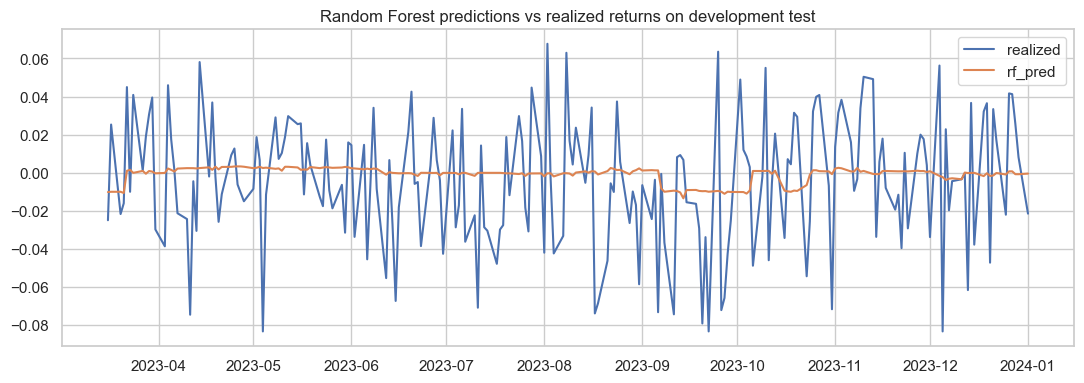

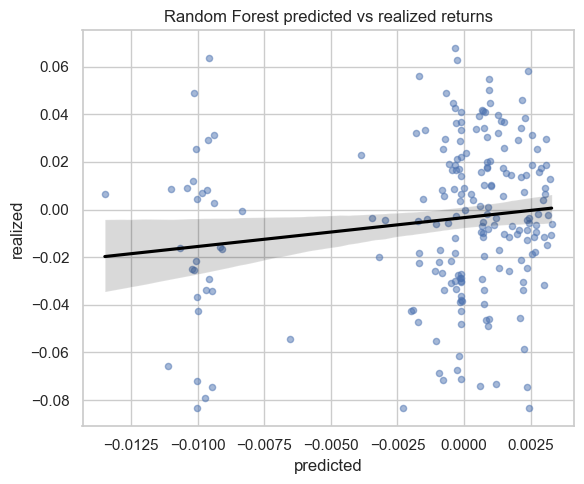

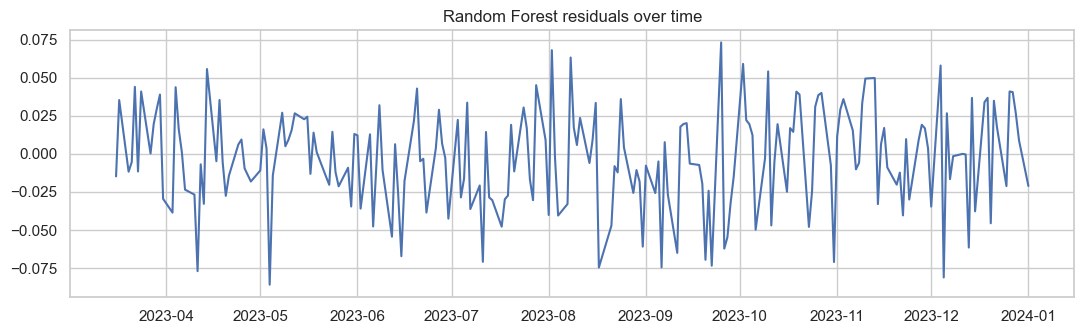

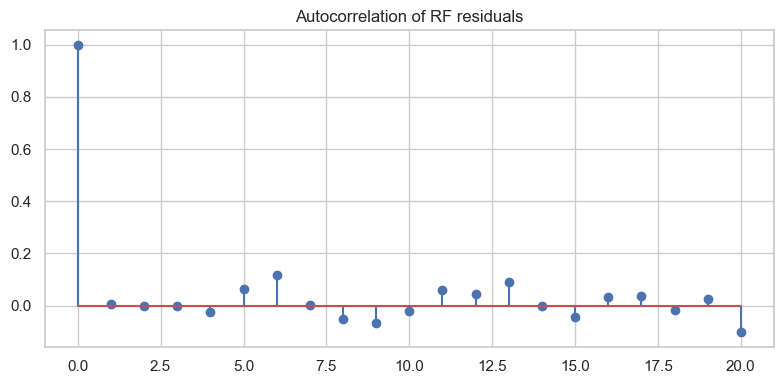

,lb_stat,lb_pvalue
5,0.970034,0.964946
10,5.447873,0.859325


In [23]:
rf_diag = pd.DataFrame({
    "date": test_df["date"].values,
    "realized": y_test.values,
    "predicted": rf_pred_test,
})
rf_diag["residual"] = rf_diag["realized"] - rf_diag["predicted"]

# --- Time series plot ---
plt.figure(figsize=(11, 4))
plt.plot(rf_diag["date"], rf_diag["realized"], label="realized")
plt.plot(rf_diag["date"], rf_diag["predicted"], label="rf_pred")
plt.title("Random Forest predictions vs realized returns on development test")
plt.legend()
plt.tight_layout()
plt.show()

# --- Scatter plot ---
plt.figure(figsize=(6, 5))
sns.regplot(
    data=rf_diag,
    x="predicted",
    y="realized",
    scatter_kws={"alpha": 0.5, "s": 20},
    line_kws={"color": "black"}
)
plt.title("Random Forest predicted vs realized returns")
plt.tight_layout()
plt.show()

# --- Residuals over time ---
plt.figure(figsize=(11, 3.5))
plt.plot(rf_diag["date"], rf_diag["residual"])
plt.title("Random Forest residuals over time")
plt.tight_layout()
plt.show()

# --- ACF of residuals ---
acf_vals = acf(rf_diag["residual"], nlags=20, fft=False)
plt.figure(figsize=(8, 4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.title("Autocorrelation of RF residuals")
plt.tight_layout()
plt.show()

# --- Ljung-Box test ---
display(acorr_ljungbox(rf_diag["residual"], lags=[5, 10], return_df=True))

Same overall conclusion as Ridge: Random Forest captures only marginally more signal (slightly higher dispersion and correlation), but predictive power remains weak and dominated by noise

## 10. Walk-forward validation — signal stability over time

Before translating predictions into a trading strategy, I verify that the Ridge signal is stable across time. The walk-forward uses `TimeSeriesSplit` on the full development set: each fold trains on expanding historical data and tests on a subsequent block. A consistently positive predictive correlation across folds indicates temporal robustness rather than a one-time fit.

In [24]:
wf_df = dev_fe.copy().dropna(subset=features + ["target_return_next_day"]).reset_index(drop=True)

X_wf = wf_df[features]
y_wf = wf_df["target_return_next_day"]
dates_wf = wf_df["date"]

tscv_wf = TimeSeriesSplit(n_splits=5)

wf_rows = []
for fold, (train_idx, test_idx) in enumerate(tscv_wf.split(X_wf), start=1):
    X_tr, y_tr = X_wf.iloc[train_idx], y_wf.iloc[train_idx]
    X_te, y_te = X_wf.iloc[test_idx], y_wf.iloc[test_idx]
    d_te = dates_wf.iloc[test_idx]

    ridge_fold = Pipeline([("scaler", StandardScaler()),
        ("model", Ridge(alpha=grid_ridge.best_params_["model__alpha"]))])
    ridge_fold.fit(X_tr, y_tr)
    y_pred = ridge_fold.predict(X_te)

    fold_corr = np.corrcoef(y_te, y_pred)[0, 1] if np.std(y_pred) > 1e-12 else np.nan

    wf_rows.append({
        "fold": fold,
        "train_end": dates_wf.iloc[train_idx].max().strftime("%Y-%m-%d"),
        "test_start": d_te.min().strftime("%Y-%m-%d"),
        "test_end": d_te.max().strftime("%Y-%m-%d"),
        "n_train": len(train_idx), "n_test": len(test_idx),
        "rmse": round(np.sqrt(mean_squared_error(y_te, y_pred)), 6),
        "corr": round(fold_corr, 4),
    })

wf_results = pd.DataFrame(wf_rows)
display(wf_results)

print(f"\nMean correlation: {wf_results['corr'].mean():.4f} ± {wf_results['corr'].std():.4f}")

,fold,train_end,test_start,test_end,n_train,n_test,rmse,corr
0,1,2020-08-31,2020-09-01,2021-04-30,174,174,0.030793,0.1040
1,2,2021-04-30,2021-05-03,2021-12-30,348,174,0.033231,0.1769
2,3,2021-12-30,2021-12-31,2022-08-31,522,174,0.029394,0.1579
3,4,2022-08-31,2022-09-01,2023-05-02,696,174,0.034745,0.1873
4,5,2023-05-02,2023-05-03,2024-01-01,870,174,0.033708,0.0878



Mean correlation: 0.1428 ± 0.0444


The Ridge walk-forward shows consistently positive predictive correlation across all 5 folds, ranging from 0.088 to 0.187 with a mean of **0.143 ± 0.044**. No fold is negative. This temporal stability is a necessary condition before translating the signal into a trading strategy — a high average correlation driven by a single fold would be much less trustworthy.

The magnitude (~0.14) is modest but notable for a daily return prediction task, where correlations above 0.05 are already considered meaningful by practitioners.

## 11. Translate predictions into trading strategies

In [25]:
def backtest_from_prediction(y_true, y_pred, dates, cost_per_turnover=0.0005, clip_at=1.0):
    y_true = pd.Series(np.asarray(y_true), index=pd.Index(dates), name="asset_return")
    y_pred = pd.Series(np.asarray(y_pred), index=pd.Index(dates), name="prediction")

    scale = y_pred.std() + 1e-12
    position = (y_pred / scale).clip(-clip_at, clip_at)

    turnover = position.diff().abs().fillna(position.abs())
    gross = position * y_true
    net = gross - cost_per_turnover * turnover

    out = pd.DataFrame({
        "date": y_true.index,
        "asset_return": y_true.values,
        "prediction": y_pred.values,
        "position": position.values,
        "turnover": turnover.values,
        "strategy_return": net.values,
    }).set_index("date")

    out["cum_return"] = (1 + out["strategy_return"]).cumprod()
    return out


def backtest_hold(y_true, dates, cost_per_turnover=0.0005):
    y_true = pd.Series(np.asarray(y_true), index=pd.Index(dates), name="asset_return")
    position = pd.Series(1.0, index=y_true.index, name="position")

    turnover = position.diff().abs().fillna(position.abs())
    gross = position * y_true
    net = gross - cost_per_turnover * turnover

    out = pd.DataFrame({
        "date": y_true.index,
        "asset_return": y_true.values,
        "prediction": np.nan,
        "position": position.values,
        "turnover": turnover.values,
        "strategy_return": net.values,
    }).set_index("date")

    out["cum_return"] = (1 + out["strategy_return"]).cumprod()
    return out


# Refit final models on all development data
X_dev_all = dev_fe[features]
y_dev_all = dev_fe["target_return_next_day"]

final_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=grid_ridge.best_params_["model__alpha"]))
])
final_ridge.fit(X_dev_all, y_dev_all)

final_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=grid_rf.best_params_["model__n_estimators"],
    max_depth=grid_rf.best_params_["model__max_depth"],
    min_samples_leaf=grid_rf.best_params_["model__min_samples_leaf"],
)
final_rf.fit(X_dev_all, y_dev_all)

# Predictions on full sample
feat_df = feat_df.copy()
feat_df["ridge_pred_fullsample_refit"] = final_ridge.predict(feat_df[features])
feat_df["rf_pred_fullsample_refit"] = final_rf.predict(feat_df[features])

# Predictions on holdout
holdout_ridge_pred = final_ridge.predict(X_holdout)
holdout_rf_pred = final_rf.predict(X_holdout)

# Full sample backtests - strength only
full_ridge_strength_bt = backtest_from_prediction(
    feat_df["target_return_next_day"],
    feat_df["ridge_pred_fullsample_refit"],
    feat_df["date"]
)

full_rf_strength_bt = backtest_from_prediction(
    feat_df["target_return_next_day"],
    feat_df["rf_pred_fullsample_refit"],
    feat_df["date"]
)

full_hold_bt = backtest_hold(
    feat_df["target_return_next_day"],
    feat_df["date"]
)

# Holdout backtests - strength only
holdout_ridge_strength_bt = backtest_from_prediction(
    y_holdout,
    holdout_ridge_pred,
    holdout_fe["date"]
)

holdout_rf_strength_bt = backtest_from_prediction(
    y_holdout,
    holdout_rf_pred,
    holdout_fe["date"]
)

holdout_hold_bt = backtest_hold(
    y_holdout,
    holdout_fe["date"]
)

In [26]:
def strategy_summary(bt_df, label):
    r = bt_df["strategy_return"]
    mean_daily = r.mean()
    std_daily = r.std()
    sharpe = np.sqrt(252) * mean_daily / (std_daily + 1e-12)
    ann_return = (1 + mean_daily) ** 252 - 1
    max_dd = (bt_df["cum_return"] / bt_df["cum_return"].cummax() - 1).min()

    return {
        "strategy": label,
        "mean_daily_return": float(mean_daily),
        "annualized_return": float(ann_return),
        "annualized_vol": float(std_daily * np.sqrt(252)),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd),
        "avg_turnover": float(bt_df["turnover"].mean()),
        "annualized_turnover": float(bt_df["turnover"].mean() * 252),
    }

full_perf = pd.DataFrame([
    strategy_summary(full_ridge_strength_bt, "Ridge strength"),
    strategy_summary(full_rf_strength_bt, "RF strength"),
    strategy_summary(full_hold_bt, "Hold"),
]).sort_values("sharpe", ascending=False)

holdout_perf = pd.DataFrame([
    strategy_summary(holdout_ridge_strength_bt, "Ridge strength"),
    strategy_summary(holdout_rf_strength_bt, "RF strength"),
    strategy_summary(holdout_hold_bt, "Hold"),
]).sort_values("sharpe", ascending=False)

print("Full-sample trading performance")
display(full_perf)

print("Final holdout trading performance")
display(holdout_perf)

Full-sample trading performance


,strategy,mean_daily_return,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,annualized_turnover
1,RF strength,0.004121,1.818953,0.332944,3.119145,-0.202055,0.092247,23.246263
0,Ridge strength,0.004174,1.856658,0.379575,2.771103,-0.258409,0.155437,39.170127
2,Hold,0.000819,0.229258,0.536463,0.384920,-0.968957,0.000767,0.193252


Final holdout trading performance


,strategy,mean_daily_return,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,annualized_turnover
0,Ridge strength,0.003833,1.622449,0.508421,1.899913,-0.271320,0.119683,30.160176
1,RF strength,0.002280,0.775004,0.404269,1.420975,-0.248567,0.130957,33.001095
2,Hold,-0.006546,-0.808895,0.560292,-2.944015,-0.862609,0.003846,0.969231


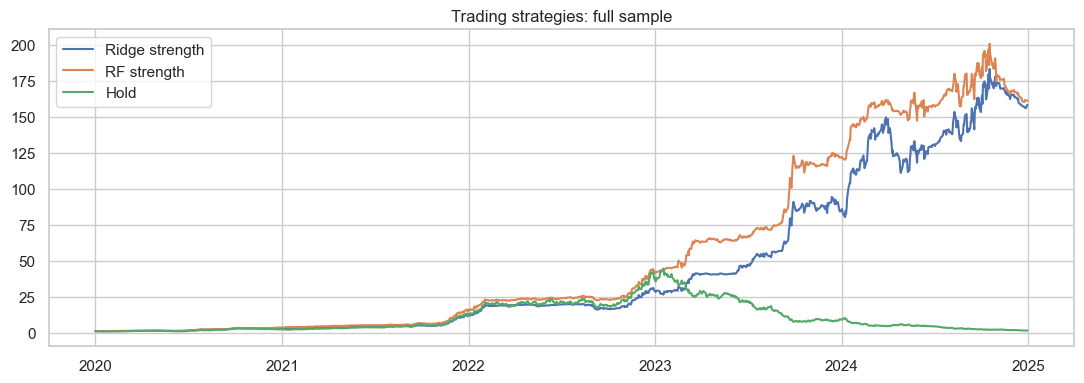

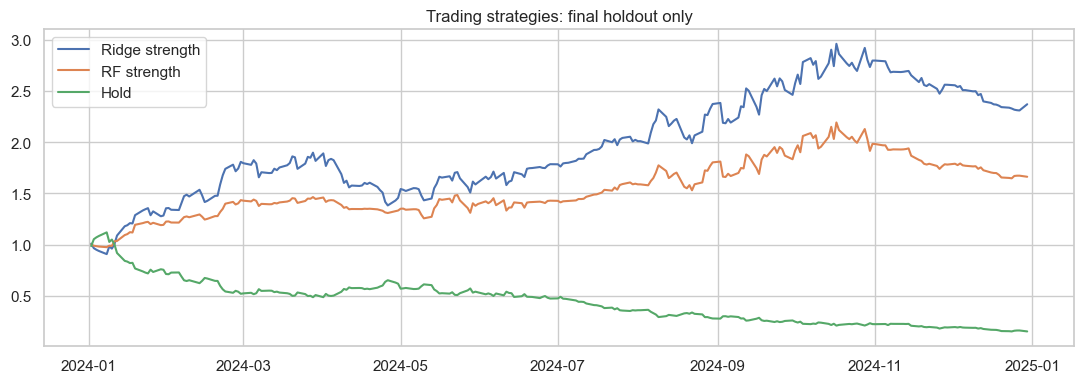

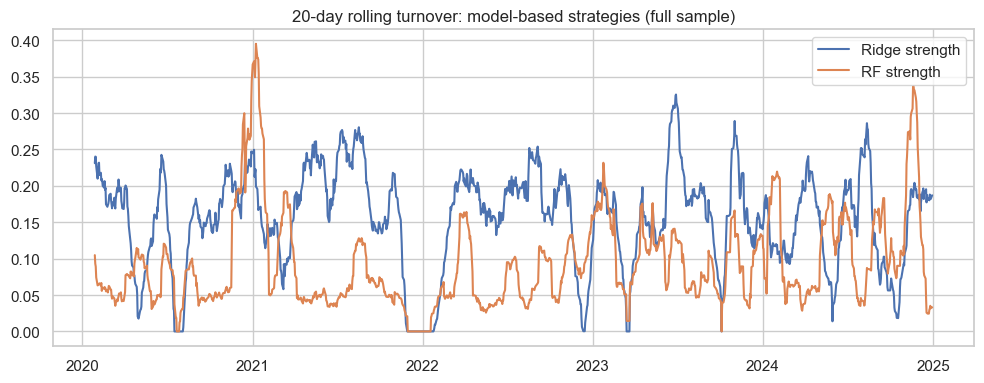

In [27]:
# --- Full sample cumulative returns ---
plt.figure(figsize=(11, 4))
plt.plot(full_ridge_strength_bt.index, full_ridge_strength_bt["cum_return"], label="Ridge strength")
plt.plot(full_rf_strength_bt.index, full_rf_strength_bt["cum_return"], label="RF strength")
plt.plot(full_hold_bt.index, full_hold_bt["cum_return"], label="Hold")
plt.title("Trading strategies: full sample")
plt.legend()
plt.tight_layout()
plt.show()

# --- Holdout cumulative returns ---
plt.figure(figsize=(11, 4))
plt.plot(holdout_ridge_strength_bt.index, holdout_ridge_strength_bt["cum_return"], label="Ridge strength")
plt.plot(holdout_rf_strength_bt.index, holdout_rf_strength_bt["cum_return"], label="RF strength")
plt.plot(holdout_hold_bt.index, holdout_hold_bt["cum_return"], label="Hold")
plt.title("Trading strategies: final holdout only")
plt.legend()
plt.tight_layout()
plt.show()

# --- Turnover (full sample) ---
plt.figure(figsize=(10, 4))
plt.plot(full_ridge_strength_bt.index, full_ridge_strength_bt["turnover"].rolling(20).mean(), label="Ridge strength")
plt.plot(full_rf_strength_bt.index, full_rf_strength_bt["turnover"].rolling(20).mean(), label="RF strength")
plt.title("20-day rolling turnover: model-based strategies (full sample)")
plt.legend()
plt.tight_layout()
plt.show()

Key observations:
- RF outperforms Ridge in-sample (Sharpe 3.12 vs 2.77) but shows larger decay on the holdout (Sharpe 1.42 vs 1.90), indicating overfitting to in-sample noise
- Ridge delivers more stable out-of-sample performance and retains a higher fraction of its in-sample Sharpe — consistent with a weak-signal environment where aggressive regularization helps
- The hold benchmark has a negative holdout Sharpe (−2.94), meaning the underlying asset lost money over the holdout period — the Ridge strategy's positive Sharpe (1.90) represents genuine alpha, not just market beta
- In a production context, Ridge would be preferred for its better generalization and lower overfitting risk

In [28]:
# --- Sensitivity of holdout Ridge-strength Sharpe to transaction costs ---

cost_bps_grid = [0, 5, 10, 15, 20, 25, 30]

ridge_cost_sensitivity_rows = []

for cost_bps in cost_bps_grid:
    cost_decimal = cost_bps / 10000.0  # 1 bp = 0.0001
    
    bt = backtest_from_prediction(
        y_holdout,
        holdout_ridge_pred,
        holdout_fe["date"],
        cost_per_turnover=cost_decimal
    )
    
    perf = strategy_summary(bt, f"Ridge strength ({cost_bps} bps)")
    
    ridge_cost_sensitivity_rows.append({
        "transaction_cost_bps": cost_bps,
        "mean_daily_return": perf["mean_daily_return"],
        "annualized_return": perf["annualized_return"],
        "annualized_vol": perf["annualized_vol"],
        "sharpe": perf["sharpe"],
        "max_drawdown": perf["max_drawdown"],
        "avg_turnover": perf["avg_turnover"],
        "annualized_turnover": perf["annualized_turnover"],
    })

ridge_cost_sensitivity = pd.DataFrame(ridge_cost_sensitivity_rows)

print("Holdout sensitivity of Ridge-strength strategy to transaction costs")
display(ridge_cost_sensitivity)

Holdout sensitivity of Ridge-strength strategy to transaction costs


,transaction_cost_bps,mean_daily_return,annualized_return,annualized_vol,sharpe,max_drawdown,avg_turnover,annualized_turnover
0,0,0.003893,1.662141,0.508333,1.929908,-0.27132,0.119683,30.160176
1,5,0.003833,1.622449,0.508421,1.899913,-0.27132,0.119683,30.160176
2,10,0.003773,1.583347,0.508514,1.869911,-0.27132,0.119683,30.160176
3,15,0.003713,1.544825,0.508611,1.839903,-0.27132,0.119683,30.160176
4,20,0.003654,1.506875,0.508713,1.809890,-0.27132,0.119683,30.160176
5,25,0.003594,1.469490,0.508820,1.779874,-0.27132,0.119683,30.160176
6,30,0.003534,1.432659,0.508931,1.749853,-0.27132,0.119683,30.160176


--> 
- Relatively mild Sharpe decay as transaction costs increase, this is a reassuring sign of robustness given the observed turnover (~30 annualized)
- Additional effects such as slippage market impact are not captured here and could further affect realized performance

## 12. Statistical inference on strategy returns

In [29]:
def iid_ttest_summary(strategy_returns):
    r = pd.Series(strategy_returns).dropna()
    t_stat, p_value = stats.ttest_1samp(r, 0.0)
    return {
        "n_obs": int(len(r)),
        "mean_return": float(r.mean()),
        "t_stat_iid": float(t_stat),
        "p_value_iid": float(p_value),
    }


def newey_west_mean_test(strategy_returns, maxlags=5):
    r = pd.Series(strategy_returns).dropna()
    X = np.ones((len(r), 1))
    fit = sm.OLS(r.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return {
        "mean_return": float(fit.params[0]),
        "se_newey_west": float(fit.bse[0]),
        "t_stat_newey_west": float(fit.tvalues[0]),
        "p_value_newey_west": float(fit.pvalues[0]),
        "maxlags": int(maxlags),
    }

In [30]:
# Holdout inference: use one consistent naming convention everywhere
holdout_inference = {
    "Ridge strength": holdout_ridge_strength_bt["strategy_return"],
    "Hold": holdout_hold_bt["strategy_return"],
}

iid_rows = []
nw_rows = []
raw_pvals = []

for label, r in holdout_inference.items():
    iid_stats = iid_ttest_summary(r)
    iid_rows.append({
        "strategy": label,
        "n_obs": iid_stats["n_obs"],
        "mean_return": iid_stats["mean_return"],
        "t_stat_iid": iid_stats["t_stat_iid"],
        "p_value_iid": iid_stats["p_value_iid"],
    })

    nw_stats = newey_west_mean_test(r, maxlags=5)
    nw_rows.append({
        "strategy": label,
        "mean_return": nw_stats["mean_return"],
        "se_newey_west": nw_stats["se_newey_west"],
        "t_stat_newey_west": nw_stats["t_stat_newey_west"],
        "p_value_newey_west": nw_stats["p_value_newey_west"],
        "maxlags": nw_stats["maxlags"],
    })

    raw_pvals.append(nw_stats["p_value_newey_west"])

iid_table = pd.DataFrame(iid_rows)
nw_table = pd.DataFrame(nw_rows)

reject, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method="bonferroni")
nw_table["p_value_bonferroni"] = pvals_bonf
nw_table["reject_5pct_after_bonferroni"] = reject

print("IID t-test summary (holdout only)")
display(iid_table)

print("Newey-West mean test with Bonferroni correction across tested strategies (holdout only)")
display(nw_table)

IID t-test summary (holdout only)


,strategy,n_obs,mean_return,t_stat_iid,p_value_iid
0,Ridge strength,260,0.003833,1.929834,0.054719
1,Hold,260,-0.006546,-2.990381,0.003055


Newey-West mean test with Bonferroni correction across tested strategies (holdout only)


,strategy,mean_return,se_newey_west,t_stat_newey_west,p_value_newey_west,maxlags,p_value_bonferroni,reject_5pct_after_bonferroni
0,Ridge strength,0.003833,0.001889,2.029713,0.042386,5,0.084771,False
1,Hold,-0.006546,0.001999,-3.273923,0.001061,5,0.002121,True


The IID t-test gives p = 0.055 for the Ridge strategy on the holdout — borderline. The Newey-West correction (accounting for potential autocorrelation in strategy returns) yields p = 0.042, which is nominally significant. However, after **Bonferroni correction** for testing two strategies (Ridge + Hold), the adjusted p-value rises to **0.085** — no longer significant at the 5% level.

This is the expected outcome given the signal strength: the walk-forward correlation of ~0.14 translates into a modest but real edge, but 260 holdout observations are insufficient to detect it with formal statistical confidence. The signal likely exists (consistently positive walk-forward, economically sensible feature structure, positive holdout Sharpe while the market is down), but cannot be proven beyond reasonable doubt with this sample size.

## 13. Robustness checks

In [31]:
# Robustness setup: use the exact same Ridge strength series as in Block 1
r_ridge_all = holdout_ridge_strength_bt["strategy_return"].copy()

regime_df = holdout_fe[["date", "vol_regime"]].copy()
regime_df = regime_df.merge(
    r_ridge_all.rename("strategy_return"),
    left_on="date",
    right_index=True,
    how="inner"
)

r_ridge_high = regime_df.loc[regime_df["vol_regime"] > 0.018, "strategy_return"]
r_ridge_low = regime_df.loc[regime_df["vol_regime"] <= 0.018, "strategy_return"]

# Consistency checks
print("Consistency checks")
print("Ridge strength mean (block 1 source):", float(holdout_ridge_strength_bt["strategy_return"].mean()))
print("Ridge (all) mean (block 2 source):   ", float(r_ridge_all.mean()))
print("Same number of observations:", len(holdout_ridge_strength_bt["strategy_return"].dropna()), len(r_ridge_all.dropna()))
print("Same values:", np.allclose(
    holdout_ridge_strength_bt["strategy_return"].dropna().values,
    r_ridge_all.dropna().values
))

Consistency checks
Ridge strength mean (block 1 source): 0.0038331558159667555
Ridge (all) mean (block 2 source):    0.0038331558159667555
Same number of observations: 260 260
Same values: True


In [32]:
robustness_rows = []

robustness_inference = {
    "Ridge (all)": r_ridge_all,
    "Ridge high vol": r_ridge_high,
    "Ridge low vol": r_ridge_low,
}

for label, r in robustness_inference.items():
    iid_stats = iid_ttest_summary(r)
    nw_stats = newey_west_mean_test(r, maxlags=5)

    robustness_rows.append({
        "strategy": label,
        "n_obs": iid_stats["n_obs"],
        "mean_return": iid_stats["mean_return"],
        "t_stat_iid": iid_stats["t_stat_iid"],
        "p_value_iid": iid_stats["p_value_iid"],
        "t_stat_newey_west": nw_stats["t_stat_newey_west"],
        "p_value_newey_west": nw_stats["p_value_newey_west"],
    })

robustness_table = pd.DataFrame(robustness_rows)

print("Inference summary (holdout)")
display(robustness_table.sort_values("t_stat_newey_west", ascending=False))

Inference summary (holdout)


,strategy,n_obs,mean_return,t_stat_iid,p_value_iid,t_stat_newey_west,p_value_newey_west
0,Ridge (all),260,0.003833,1.929834,0.054719,2.029713,0.042386
1,Ridge high vol,117,0.005109,1.495342,0.137541,1.771774,0.076432
2,Ridge low vol,143,0.002789,1.215688,0.226121,1.185196,0.235940


The regime decomposition confirms that the signal is **conditional rather than uniform**:
- **High volatility** (n = 117): mean daily return 0.51%, NW t-stat 1.77, p = 0.076 — borderline significant, consistent with the §4.5 finding that `macro_signal` has a 2.3× larger coefficient in high-vol
- **Low volatility** (n = 143): mean daily return 0.28%, NW t-stat 1.19, p = 0.236 — not significant

The alpha, if it exists, is driven primarily by high-volatility periods. This is economically interpretable: macro information may propagate more slowly during stress, creating temporary mispricings that a signal based on `macro_signal` × `is_high_vol` can exploit. Outside those periods, markets are more efficient and the signal largely disappears.

Additional note: it would be worth testing robustness on pre-winsorized data, and verifying that the high-vol concentration is not driven by a single crisis episode.

## Final remarks

The analysis suggests the presence of a predictive signal driven by `macro_signal`, concentrated in high-volatility regimes. The evidence is consistent across multiple independent checks: the OLS significance analysis (§4.5) identifies `macro_signal` as the only robust predictor with a regime-dependent coefficient, the Ridge and RF models converge on `macro_high_vol` as the dominant feature (§8), the walk-forward validation shows stable positive correlation across all folds (mean 0.143 ± 0.044, §10), and the trading strategy delivers a holdout Sharpe of 1.90 while the underlying asset declines (§11).

However, formal statistical significance is not achieved after multiple-testing correction (Bonferroni-adjusted p = 0.085, §12), and the regime decomposition confirms the signal is conditional rather than uniform (§13). With only 260 holdout observations and a signal-to-noise ratio this low, the sample is too short to resolve the question definitively.

**What I would do next:**
- **Extend the holdout period** to accumulate more observations — the signal may reach significance with 2+ years of out-of-sample data
- **Test on additional assets or markets** to verify the signal generalizes beyond this specific time series
- **Investigate the macro_signal construction** more carefully — the feature appears pre-engineered and its strong predictive power warrants an audit of potential look-ahead bias
- **Implement a regime-conditional position sizing** that scales exposure with the volatility regime, rather than using a uniform signal-to-position mapping
- **Run the analysis on pre-winsorized data** as a robustness check